In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from datetime import datetime
import pandas as pd

# Импорт архитектур
from architectures import create_model

In [3]:
class GridDataset(Dataset):
    """Датасет для сегментации линий сетки"""

    def __init__(self, images_dir, masks_dir, transform=None, mask_transform=None, size=(512, 512)):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.size = size

        # Список изображений
        self.images = [f for f in os.listdir(images_dir)
                      if f.endswith(('.png', '.jpg', '.jpeg'))]

        print(f"📂 Загружено {len(self.images)} изображений из {images_dir}")

        # Трансформации
        self.transform = transform or transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize(size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])

        self.mask_transform = mask_transform or transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize(size),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.images_dir, img_name)

        # Ищем маску
        base_name = os.path.splitext(img_name)[0]
        mask_path = os.path.join(self.masks_dir, f"{base_name}_mask.png")

        if not os.path.exists(mask_path):
            # Пробуем другие форматы
            alt_path = os.path.join(self.masks_dir, f"{base_name}_mask.jpg")
            if os.path.exists(alt_path):
                mask_path = alt_path
            else:
                raise FileNotFoundError(f"Маска не найдена: {mask_path}")

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 128).astype(np.float32)

        if self.transform:
            image = self.transform(image)

        if self.mask_transform:
            mask = self.mask_transform(mask)
        else:
            mask = torch.from_numpy(mask).unsqueeze(0).float()

        return image, mask

# Метрики

In [4]:
def dice_score(pred, target, smooth=1e-6):
    """Dice coefficient"""
    pred = torch.sigmoid(pred)
    pred_flat = pred.view(-1)
    target_flat = target.view(-1)
    intersection = (pred_flat * target_flat).sum()
    return (2. * intersection + smooth) / (pred_flat.sum() + target_flat.sum() + smooth)


def iou_score(pred, target, smooth=1e-6):
    """IoU (Intersection over Union)"""
    pred = torch.sigmoid(pred)
    pred_flat = pred.view(-1)
    target_flat = target.view(-1)
    intersection = (pred_flat * target_flat).sum()
    union = pred_flat.sum() + target_flat.sum() - intersection
    return (intersection + smooth) / (union + smooth)


def precision_score(pred, target, smooth=1e-6):
    """Precision"""
    pred = torch.sigmoid(pred)
    pred_flat = pred.view(-1)
    target_flat = target.view(-1)
    intersection = (pred_flat * target_flat).sum()
    return (intersection + smooth) / (pred_flat.sum() + smooth)


def recall_score(pred, target, smooth=1e-6):
    """Recall"""
    pred = torch.sigmoid(pred)
    pred_flat = pred.view(-1)
    target_flat = target.view(-1)
    intersection = (pred_flat * target_flat).sum()
    return (intersection + smooth) / (target_flat.sum() + smooth)


def compute_metrics(outputs, masks):
    """Вычисляет все метрики для батча"""
    metrics = {}
    metrics['dice'] = dice_score(outputs, masks).item()
    metrics['iou'] = iou_score(outputs, masks).item()
    metrics['precision'] = precision_score(outputs, masks).item()
    metrics['recall'] = recall_score(outputs, masks).item()
    metrics['f1'] = 2 * (metrics['precision'] * metrics['recall']) / (metrics['precision'] + metrics['recall'] + 1e-6)
    return metrics

# Визуализация

In [5]:
def visualize_predictions(model, dataloader, device, num_samples=4, save_path=None):
    """Визуализация предсказаний модели"""
    model.eval()

    images, masks = next(iter(dataloader))
    actual_samples = min(num_samples, images.shape[0])
    images = images[:actual_samples].to(device)
    masks = masks[:actual_samples].to(device)

    with torch.no_grad():
        outputs = model(images)
        preds = torch.sigmoid(outputs)

    fig, axes = plt.subplots(actual_samples, 3, figsize=(12, actual_samples * 3))
    if actual_samples == 1:
        axes = axes.reshape(1, -1)

    for i in range(actual_samples):
        # Денормализация
        img = images[i].cpu().numpy().transpose(1, 2, 0)
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = np.clip(std * img + mean, 0, 1)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title('Оригинал')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(masks[i].cpu().squeeze(), cmap='gray')
        axes[i, 1].set_title('Истинная маска')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(preds[i].cpu().squeeze(), cmap='gray')
        axes[i, 2].set_title('Предсказание')
        axes[i, 2].axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    model.train()


def plot_training_history(history, model_name, save_dir='results'):
    """Построение графиков обучения"""
    os.makedirs(save_dir, exist_ok=True)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Loss
    axes[0].plot(history['train_loss'], label='Train Loss')
    axes[0].plot(history['val_loss'], label='Val Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{model_name} - Loss')
    axes[0].legend()
    axes[0].grid(True)

    # Dice
    axes[1].plot(history['train_dice'], label='Train Dice')
    axes[1].plot(history['val_dice'], label='Val Dice')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Dice')
    axes[1].set_title(f'{model_name} - Dice Coefficient')
    axes[1].legend()
    axes[1].grid(True)

    # IoU
    axes[2].plot(history['train_iou'], label='Train IoU')
    axes[2].plot(history['val_iou'], label='Val IoU')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('IoU')
    axes[2].set_title(f'{model_name} - IoU')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.savefig(f'{save_dir}/{model_name}_training_history.png', dpi=150)
    plt.close()

# Обучение модели

In [ ]:
def train_model(model, train_loader, val_loader, device, epochs=50, lr=1e-4, model_name="UNet"):
    """
    Обучение одной модели
    """
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5)

    history = {
        'train_loss': [], 'val_loss': [],
        'train_dice': [], 'val_dice': [],
        'train_iou': [], 'val_iou': [],
        'train_precision': [], 'val_precision': [],
        'train_recall': [], 'val_recall': [],
        'train_f1': [], 'val_f1': []
    }

    best_val_dice = 0.0
    patience_counter = 0
    patience = 5

    print(f"\n🔨 ОБУЧЕНИЕ {model_name}")
    print("="*50)

    for epoch in range(epochs):
        # TRAIN
        model.train()
        train_loss = 0
        train_metrics = {'dice': 0, 'iou': 0, 'precision': 0, 'recall': 0, 'f1': 0}

        for images, masks in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]'):
            images, masks = images.to(device), masks.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            metrics = compute_metrics(outputs, masks)
            for k in train_metrics:
                train_metrics[k] += metrics[k]

        # VALIDATION
        model.eval()
        val_loss = 0
        val_metrics = {'dice': 0, 'iou': 0, 'precision': 0, 'recall': 0, 'f1': 0}

        with torch.no_grad():
            for images, masks in tqdm(val_loader, desc=f'Epoch {epoch+1}/{epochs} [Val]'):
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)
                loss = criterion(outputs, masks)

                val_loss += loss.item()
                metrics = compute_metrics(outputs, masks)
                for k in val_metrics:
                    val_metrics[k] += metrics[k]

        # Усредняем
        n_train = len(train_loader)
        n_val = len(val_loader)

        history['train_loss'].append(train_loss / n_train)
        history['val_loss'].append(val_loss / n_val)

        for k in train_metrics:
            history[f'train_{k}'].append(train_metrics[k] / n_train)
            history[f'val_{k}'].append(val_metrics[k] / n_val)

        scheduler.step(history['val_loss'][-1])

        # Вывод
        print(f"\n📊 Epoch {epoch+1}/{epochs}")
        print(f"   Train Loss: {history['train_loss'][-1]:.4f}, Dice: {history['train_dice'][-1]:.4f}, IoU: {history['train_iou'][-1]:.4f}")
        print(f"   Val Loss: {history['val_loss'][-1]:.4f}, Dice: {history['val_dice'][-1]:.4f}, IoU: {history['val_iou'][-1]:.4f}")

        # Сохраняем лучшую модель
        current_dice = history['val_dice'][-1]
        if current_dice > best_val_dice:
            best_val_dice = current_dice
            torch.save(model.state_dict(), f'best_{model_name}.pth')
            print(f"   💾 Лучшая модель сохранена! (Dice: {best_val_dice:.4f})")
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"🛑 Early stopping на эпохе {epoch+1}")
            break

        # Early stopping
        if patience_counter >= 15:
            print(f"   ⏹️ Early stopping на эпохе {epoch+1}")
            break

    return history

# Запуск эксперимента и сравнение архитектур

In [ ]:
def run_experiment(
    train_images_dir='train_images',
    train_masks_dir='train_masks',
    val_images_dir=None,
    val_masks_dir=None,
    models_to_train=['unet', 'attention_unet', 'resunet'],
    epochs=30,
    batch_size=4,
    val_split=0.2,
    seed=42
):
    """
    Запуск эксперимента: обучение и сравнение архитектур
    """

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Устройство {device}")

    # Разделение на train/val из одной папки
    all_dataset = GridDataset(train_images_dir, train_masks_dir)
    train_size = int((1 - val_split) * len(all_dataset))
    val_size = len(all_dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(
        all_dataset, [train_size, val_size],
        generator=torch.Generator().manual_seed(seed)
    )
    print(f"📊 Train: {train_size} | Val: {val_size}")

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Результаты
    all_results = {}
    os.makedirs('results', exist_ok=True)

    # Обучение каждой модели
    for model_name in models_to_train:
        print("\n" + "="*60)
        print(f"📌 ОБУЧЕНИЕ: {model_name.upper()}")

        # Создаём модель
        model = create_model(model_name, n_channels=3, n_classes=1).to(device)

        # Подсчёт параметров
        n_params = sum(p.numel() for p in model.parameters())
        print(f"📊 Параметров: {n_params/1e6:.2f}M")

        # Обучение
        history = train_model(
            model, train_loader, val_loader, device,
            epochs=epochs, model_name=model_name
        )

        # Сохраняем историю
        all_results[model_name] = history

        # Визуализация предсказаний
        model.load_state_dict(torch.load(f'best_{model_name}.pth'))
        visualize_predictions(
            model, val_loader, device,
            save_path=f'results/{model_name}_predictions.png'
        )

        # Графики обучения
        plot_training_history(history, model_name)

    # Финальное сравнение
    print("\n" + "="*60)
    print("📊 ФИНАЛЬНОЕ СРАВНЕНИЕ АРХИТЕКТУР")

    comparison = []
    for model_name, history in all_results.items():
        best_idx = np.argmax(history['val_dice'])
        comparison.append({
            'Model': model_name.upper(),
            'Best Val Dice': history['val_dice'][best_idx],
            'Best Val IoU': history['val_iou'][best_idx],
            'Best Val F1': history['val_f1'][best_idx],
            'Best Val Loss': history['val_loss'][best_idx],
            'Epoch': best_idx + 1
        })

    df = pd.DataFrame(comparison)
    df = df.sort_values('Best Val Dice', ascending=False)
    print(df.to_string(index=False))

    df.to_csv('results/comparison_table.csv', index=False)
    plot_comparison(all_results)

    print("\n✅ Эксперимент завершён.")

    return all_results, df


def plot_comparison(all_results):
    """График сравнения архитектур"""
    plt.figure(figsize=(12, 6))

    for model_name, history in all_results.items():
        plt.plot(history['val_dice'], label=f"{model_name.upper()}", linewidth=2)

    plt.xlabel('Epoch')
    plt.ylabel('Validation Dice')
    plt.title('Сравнение архитектур U-Net на валидации')
    plt.legend()
    plt.grid(True)
    plt.savefig('results/comparison_dice.png', dpi=150)
    plt.show()

In [8]:
def predict_on_image(model_path, image_path, model_name='unet', device='cpu', size=(512, 512)):
    """
    Предсказание на одном изображении
    """
    # Загружаем модель
    model = create_model(model_name, n_channels=3, n_classes=1).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Загружаем изображение
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    original_h, original_w = image.shape[:2]

    # Трансформации
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize(size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    input_tensor = transform(image).unsqueeze(0).to(device)

    # Предсказание
    with torch.no_grad():
        output = model(input_tensor)
        pred = torch.sigmoid(output).cpu().squeeze().numpy()

    pred = cv2.resize(pred, (original_w, original_h))
    pred_binary = (pred > 0.5).astype(np.uint8) * 255

    # Визуализация
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(image)
    axes[0].set_title('Оригинал')
    axes[0].axis('off')

    axes[1].imshow(pred, cmap='gray')
    axes[1].set_title('Предсказание (вероятности)')
    axes[1].axis('off')

    axes[2].imshow(pred_binary, cmap='gray')
    axes[2].set_title('Предсказание (бинарное)')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    return pred, pred_binary


In [9]:
TRAIN_IMAGES_DIR = 'train_images'
TRAIN_MASKS_DIR = 'train_masks'
VAL_IMAGES_DIR = 'val_images'
VAL_MASKS_DIR = 'val_masks'

# Обучение

In [10]:
# results_unet, df_unet = run_experiment(
#     train_images_dir=TRAIN_IMAGES_DIR,
#     train_masks_dir=TRAIN_MASKS_DIR,
#     val_images_dir=VAL_IMAGES_DIR,
#     val_masks_dir=VAL_MASKS_DIR,
#     models_to_train=['unet'],
#     epochs=50,
#     batch_size=4
# )

# print("✅ Обучение UNet завершено!")

Устройство cuda
📂 Загружено 70 изображений из train_images
📊 Train: 56 | Val: 14

📌 ОБУЧЕНИЕ: RESUNET
📊 Параметров: 13.57M

🔨 ОБУЧЕНИЕ resunet


Epoch 1/50 [Val]: 100%|██████████| 4/4 [00:01<00:00,  2.66it/s]



📊 Epoch 1/50
   Train Loss: 0.4867, Dice: 0.2314, IoU: 0.1311
   Val Loss: 0.5215, Dice: 0.1911, IoU: 0.1059
   💾 Лучшая модель сохранена! (Dice: 0.1911)


Epoch 2/50 [Val]: 100%|██████████| 4/4 [00:01<00:00,  2.01it/s]



📊 Epoch 2/50
   Train Loss: 0.4436, Dice: 0.2509, IoU: 0.1438
   Val Loss: 0.4264, Dice: 0.2138, IoU: 0.1200
   💾 Лучшая модель сохранена! (Dice: 0.2138)


...


📊 Epoch 43/50
   Train Loss: 0.2896, Dice: 0.3256, IoU: 0.1950
   Val Loss: 0.2680, Dice: 0.2878, IoU: 0.1690


Epoch 44/50 [Val]: 100%|██████████| 4/4 [00:01<00:00,  2.61it/s]



📊 Epoch 44/50
   Train Loss: 0.2860, Dice: 0.3326, IoU: 0.1999
   Val Loss: 0.2711, Dice: 0.2905, IoU: 0.1709


Epoch 45/50 [Val]: 100%|██████████| 4/4 [00:01<00:00,  2.43it/s]



📊 Epoch 45/50
   Train Loss: 0.2830, Dice: 0.3313, IoU: 0.1994
   Val Loss: 0.2671, Dice: 0.2913, IoU: 0.1715
🛑 Early stopping на эпохе 45


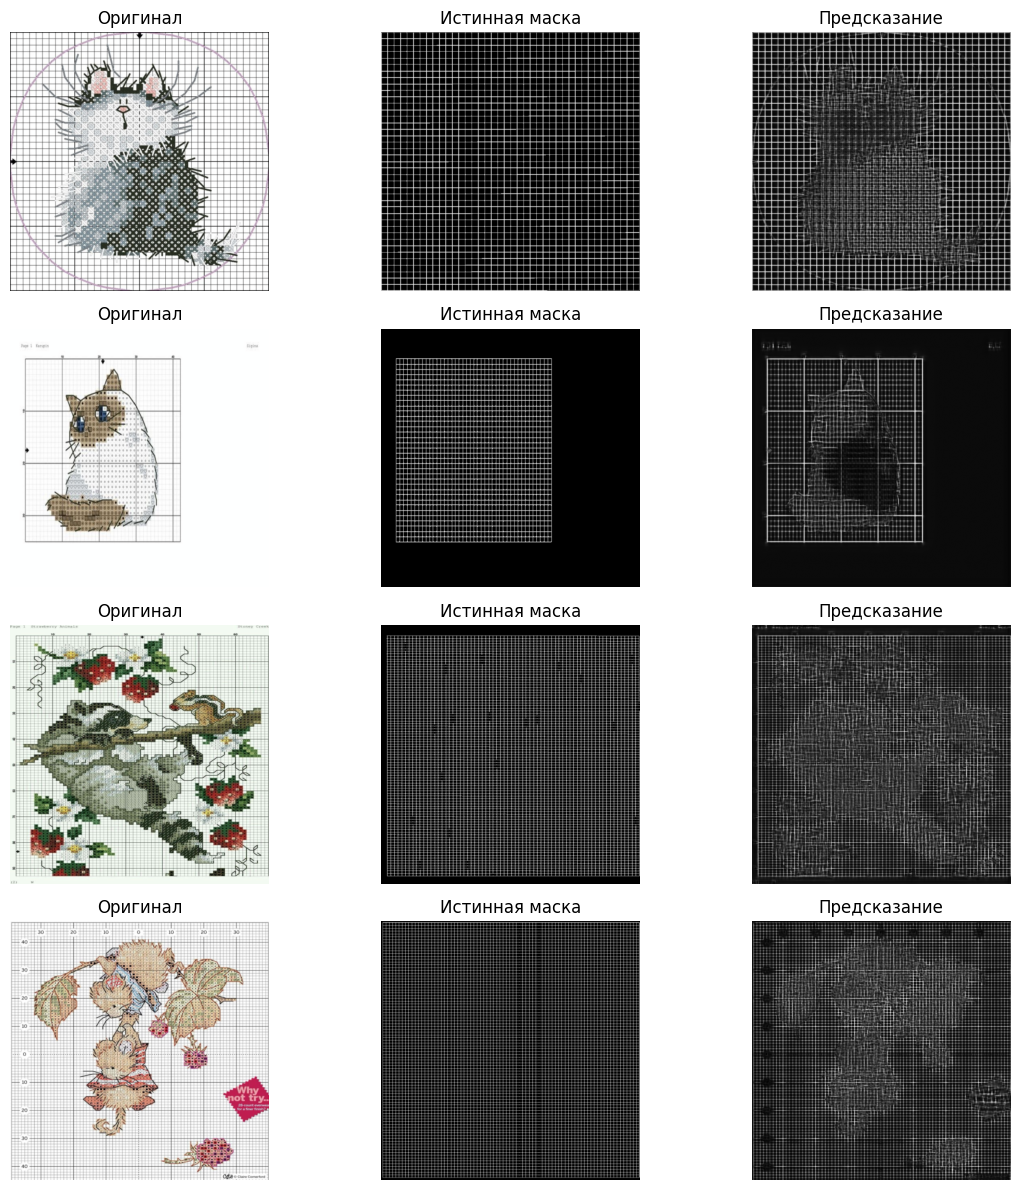


📊 ФИНАЛЬНОЕ СРАВНЕНИЕ АРХИТЕКТУР
  Model  Best Val Dice  Best Val IoU  Best Val F1  Best Val Loss  Epoch
RESUNET       0.296485      0.175074     0.296485       0.270007     40


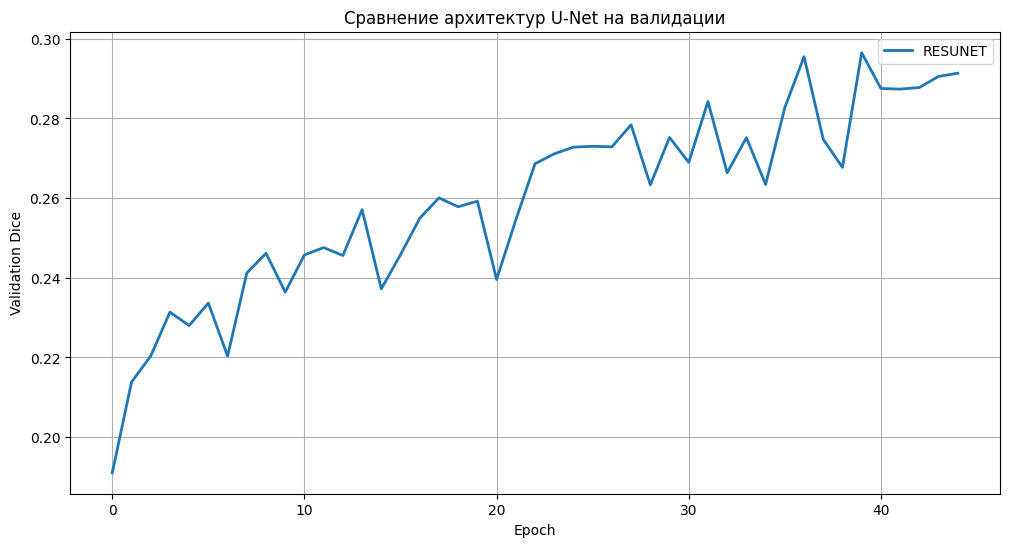


✅ Эксперимент завершён.
✅ Обучение ResU-Net завершено!


In [13]:
results_res, df_res = run_experiment(
    train_images_dir=TRAIN_IMAGES_DIR,
    train_masks_dir=TRAIN_MASKS_DIR,
    val_images_dir=VAL_IMAGES_DIR,
    val_masks_dir=VAL_MASKS_DIR,
    models_to_train=['resunet'],
    epochs=50,
    batch_size=4
)

print("✅ Обучение ResU-Net завершено!")